In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/navic_sample.csv")

In [6]:
features = [
    "CNo",
    "Elevation",
    "Azimuth",
    "Doppler",
    "LockTime",
    "RangeResidual",
    "SatCount"
]

X = df[features].copy()

In [7]:
X = X.fillna(X.median())

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

model.fit(X_scaled)

df["anomaly"] = model.predict(X_scaled)

In [10]:
df["anomaly"] = df["anomaly"].map({1:0,-1:1})

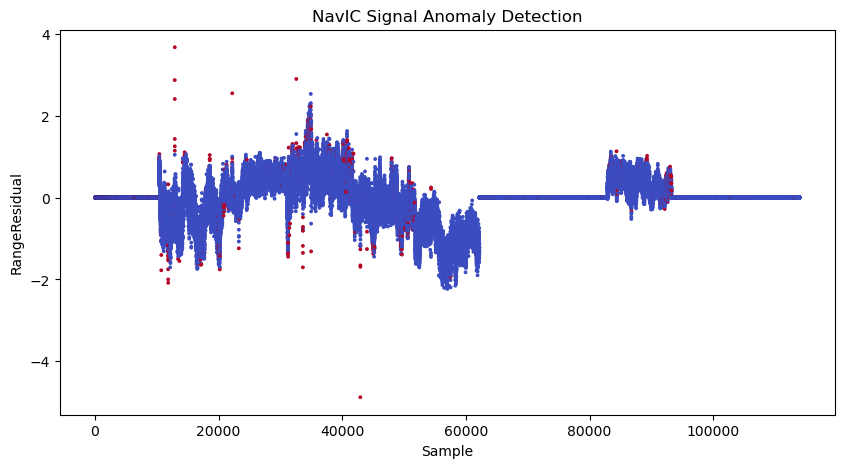

In [11]:
plt.figure(figsize=(10,5))

plt.scatter(
    df.index,
    df["RangeResidual"],
    c=df["anomaly"],
    cmap="coolwarm",
    s=3
)

plt.title("NavIC Signal Anomaly Detection")
plt.xlabel("Sample")
plt.ylabel("RangeResidual")

plt.show()

In [12]:
anomalies = df[df["anomaly"]==1]

anomalies.head()

,Channel,CNo,Elevation,Azimuth,Doppler,LockTime,RejectCode,TrackingStatus,RangeResidual,SatCount,anomaly
23,1,50.032112,0.0,0.0,-1968.248779,23,1342427520,3604,0.0,7,1
24,1,49.539688,0.0,0.0,-1968.127075,24,1342427520,3604,0.0,7,1
25,1,49.541172,0.0,0.0,-1968.291748,25,1342427520,3604,0.0,7,1
26,1,49.666935,0.0,0.0,-1967.812866,26,1342427520,2580,0.0,7,1
27,1,49.644012,0.0,0.0,-1967.923340,27,1342427520,2580,0.0,7,1


In [13]:
anomalies.to_csv("../outputs/navic_anomalies.csv",index=False)